In [84]:
import pandas as pd
import numpy as np
import model_init as mi
import matplotlib.pyplot as plt
from parameters import *  # ← pulls in all the parameters defined in that file
from infiltration_models import *

#### Input data

### Interception from VIC model

In [8]:
"""interception: Liang et al. (1994):  https://doi.org/10.1029/94JD00483"""

def compute_canopy_wb(time):
    """
    Compute daily canopy water balance using Liang et al. (1994) model.
    Returns a pandas Series of daily interception values.
    """
    #get date from index
    timestep = mi.pET_k.index[time]
    day = timestep.normalize()               # midnight of that day

    I_max = max(0.0, mi.k1 * mi.dailyLAI.loc[day])  # Maximum interception capacity (mm)

    if time == 0:
        I_prev = mi.interception[0]
    else:
        I_prev = float(mi.interception[time - 1])

    #wetness factor beta = (I_prev / I_max) ^ (2/3)
    if I_prev >0 and I_max >0 and mi.pET_k.iloc[time] >0:  
        beta = (I_prev / I_max) ** (2.0/3.0)
        Ec_max = beta * mi.pET_k.iloc[time]  # Maximum evaporation from interception (mm/timestep)
        Ec_max = max(0.0, Ec_max)
    else:
        Ec_max = 0.0
    
    #fraction of time canopy stays wet
    if Ec_max >0:
        f = min(1.0, (I_prev + mi.precip.iloc[time]) / Ec_max)
    else:
        f = 0.0
    
    #Actual canopy evaporation
    Ec = f * Ec_max #mm
    Ec = min(Ec, I_prev + mi.precip.iloc[time])  # cannot evaporate more than available water

    #update canopy interception storage after precipitation and evaporation
    I_after = I_prev + mi.precip.iloc[time] - Ec
    I_new = min(I_max, max(0.0, I_after))  # cannot exceed maximum interception capacity

    #Throuhfall
    throughfall = max(0.0, I_after - I_max)

    mi.interception[time] = I_new
    mi.throughfall[time] = throughfall
    mi.canopy_evap[time] = Ec

    #remaining PET after interception evaporation
    remaining_PET = max(0.0, mi.pET_k.iloc[time] - Ec)

In [10]:
#Vegetation interception
precip   = mi.precip
dailyLAI = mi.dailyLAI
n_steps = len(precip)

for time in range(n_steps):
    model = compute_canopy_wb(time)

#convert to dataframe for easier plotting
results_df_daily = pd.DataFrame({
    'canopy_evap': mi.canopy_evap,
    'interception': mi.interception,
    'throughfall': mi.throughfall
})
results_df_daily.index = precip.index

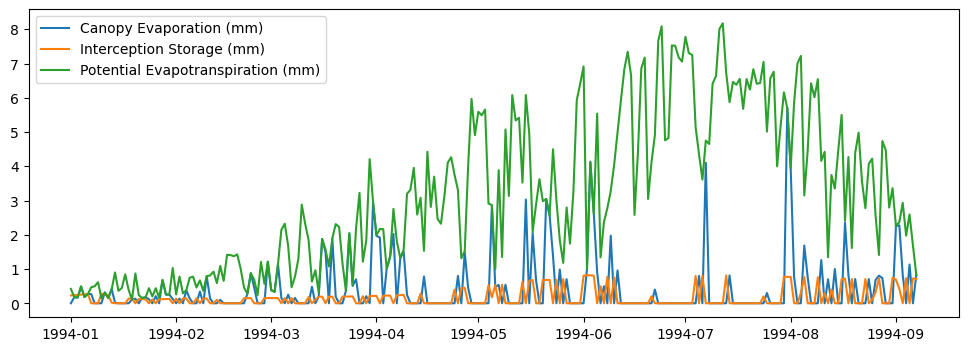

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(results_df_daily['canopy_evap'][0:250], label='Canopy Evaporation (mm)')
plt.plot(results_df_daily['interception'][0:250], label='Interception Storage (mm)')
plt.plot(mi.pET_k[0:250], label='Potential Evapotranspiration (mm)')
# plt.plot(results_df_daily['throughfall'][0:250], label='Throughfall (mm)')
plt.legend()

#### Step 1: Data Processing
#### Disaggregate daily to hourly meteorology

In [ ]:
def _monthly_daylength_hours(lat_deg):
    """
    Monthly daylength (hours, float) for the 15th of each month at latitude lat_deg.
    Geometric daylength (no refraction correction).
    """
    lat = np.deg2rad(lat_deg)
    doy_15 = np.array([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349], dtype=float)

    delta = np.deg2rad(23.44) * np.sin(2*np.pi*(284 + doy_15)/365.0)
    x = -np.tan(lat) * np.tan(delta)
    x = np.clip(x, -1.0, 1.0)

    omega = np.arccos(x)
    daylen = 24.0/np.pi * omega
    return np.clip(daylen, 0.0, 24.0)

def _disagg_pet_smooth(PET_d, date, latitude, fnight_pet=0.0):
    """
    Disaggregate one daily PET total (mm/day) to 24 hourly PET (mm/hour)
    using a smooth half-sine diurnal shape during daylight.

    fnight_pet: fraction (0..1) of PET assigned uniformly to night hours.
               Typically small (0.0–0.15). If 0, night PET is exactly 0.
    """
    if PET_d <= 0:
        return np.zeros(24, dtype=float)

    month = date.month
    daylen = _monthly_daylength_hours(latitude)[month - 1]  # float hours

    # Handle polar edge cases (not relevant for Belgium but safe)
    if daylen <= 0.0:
        # all "night"
        hourly = np.full(24, PET_d / 24.0, dtype=float) if fnight_pet > 0 else np.zeros(24, dtype=float)
        return hourly
    if daylen >= 24.0:
        # all "day"
        return np.full(24, PET_d / 24.0, dtype=float)

    # Define sunrise/sunset centered around noon
    sunrise = 12.0 - daylen / 2.0
    sunset  = 12.0 + daylen / 2.0

    hours = np.arange(24, dtype=float)
    day_mask = (hours >= sunrise) & (hours < sunset)

    # Night allocation (uniform over night hours)
    hourly = np.zeros(24, dtype=float)
    PET_night = PET_d * fnight_pet
    PET_day = PET_d - PET_night

    n_night = 24 - int(day_mask.sum())
    if n_night > 0 and PET_night > 0:
        hourly[~day_mask] = PET_night / n_night

    # Day allocation with half-sine weights (smooth, peak at noon)
    if PET_day > 0 and day_mask.any():
        # map each daylight hour to [0, pi]
        t = (hours[day_mask] + 0.5 - sunrise) / daylen  # +0.5 uses hour-center
        w = np.sin(np.pi * t)                            # half-sine shape
        w = np.maximum(w, 0.0)
        w_sum = w.sum()
        if w_sum > 0:
            hourly[day_mask] = PET_day * (w / w_sum)
        else:
            # fallback: uniform over day hours
            hourly[day_mask] = PET_day / day_mask.sum()

    # Conservation check
    if not np.isclose(hourly.sum(), PET_d, atol=1e-10):
        # minor floating error fix
        hourly *= PET_d / hourly.sum()

    return hourly

def generate_hourly_pet(pet_daily: pd.Series, latitude, fnight_pet=0.05):
    daily = pet_daily.copy()
    daily.index = daily.index.normalize()

    hourly_vals = np.empty(len(daily) * 24, dtype=float)
    hourly_times = np.empty(len(daily) * 24, dtype="datetime64[ns]")

    for i, date in enumerate(daily.index):
        PET_h = _disagg_pet_smooth(daily.iloc[i], date, latitude=latitude, fnight_pet=fnight_pet)
        sl = slice(i*24, (i+1)*24)
        hourly_vals[sl] = PET_h
        hourly_times[sl] = pd.date_range(date, periods=24, freq="h").values

    return pd.DataFrame({"pet_h": hourly_vals}, index=pd.DatetimeIndex(hourly_times))


In [191]:
pet_df=generate_hourly_pet(mi.pET_k, latitude=51.45, fnight_pet=0.05)

<Axes: title={'center': 'Hourly PET Time Series'}, xlabel='time', ylabel='PET (mm)'>

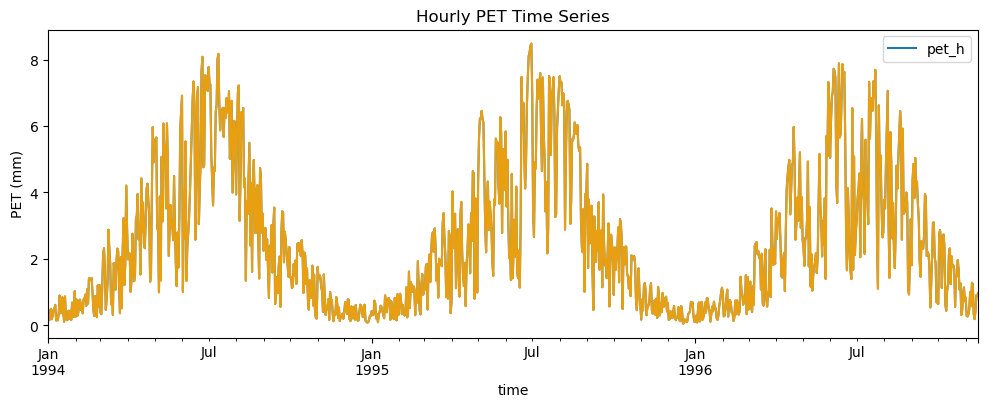

In [60]:
fig, ax = plt.subplots(figsize=(12, 4))
pet_df.resample('D').sum()[0:1050].plot(ax=ax, title='Hourly PET Time Series', ylabel='PET (mm)')
mi.pET_k[0:1050].plot(ax=ax, alpha=0.9, label='Original daily PET', c='orange')

#### Disaggregate daily precipitation to hourly

In [ ]:
def disagg_P_hourly(daily_precip, dn_ratios_df, month, day_start=6, day_end=18):
    """
    Disaggregate one daily precipitation total (mm/day) to 24 hourly precipitation (mm/hour),
    using month-specific day/night ratios. Day hours are defined by day_start and day_end.

    Inputs:
    - daily_precip: float, daily precipitation total (mm/day)
    - dn_ratios_df: DataFrame, with columns 'day_ratio' and 'night_ratio' indexed by month (1-12)
    - month: int, month of the year (1-12)
    - day_start: int, hour of day when daytime starts (default: 6)
    - day_end: int, hour of day when daytime ends (default: 18)
    Outputs:
    - hourly: ndarray of shape (24,), hourly precipitation (mm/hour)

    """

    day_ratio  = float(dn_ratios_df.loc[month, 'day_ratio'])
    night_ratio = float(dn_ratios_df.loc[month, 'night_ratio'])

    # recommended: enforce conservation
    if not np.isclose(day_ratio + night_ratio, 1.0, atol=1e-6):
        raise ValueError(f"Month {month}: day_ratio + night_ratio != 1 (got {day_ratio + night_ratio})")

    hourly = np.zeros(24, dtype=float)
    day_hours = [(h >= day_start) and (h < day_end) for h in range(24)]

    hourly[day_hours] = daily_precip * (day_ratio / 12.0)
    hourly[~np.array(day_hours)] = daily_precip * (night_ratio / 12.0)
    return hourly

def generate_hourly_precipitation(precip_daily: pd.Series, dn_ratios_df: pd.DataFrame,
                                  day_start=6, day_end=18):
    """
    Generate hourly precipitation DataFrame from daily precipitation Series.
    """
    daily = precip_daily.copy()
    daily.index = daily.index.normalize()

    hourly_index = pd.date_range(daily.index.min(),
                                 daily.index.max() + pd.Timedelta(hours=23),
                                 freq="h")

    hourly_vals = np.empty(len(daily) * 24, dtype=float)

    for i, date in enumerate(daily.index):
        hourly_vals[i*24:(i+1)*24] = disagg_P_hourly(
            daily_precip=daily.iloc[i],
            dn_ratios_df=dn_ratios_df,
            month=date.month,
            day_start=day_start,
            day_end=day_end
        )

    return pd.DataFrame({"pre_h": hourly_vals}, index=hourly_index)

In [413]:
def initialize_model_fluxes(daily_index, freq="H", n_layers=3):
    daily_index = pd.DatetimeIndex(daily_index).normalize()

    if freq.upper() == "D":
        out_index = daily_index
    elif freq.upper() == "H":
        out_index = pd.DatetimeIndex(
            np.concatenate([pd.date_range(d, periods=24, freq="h").values for d in daily_index])
        )
    else:
        raise ValueError("Invalid frequency. Use 'D' or 'H'.")

    n = len(out_index)

    fluxes = {
        "index": out_index,

        "interception":      np.zeros(n, dtype=float),
        "throughfall":       np.zeros(n, dtype=float),
        "canopy_evap":       np.zeros(n, dtype=float),

        "infiltration":      np.zeros(n, dtype=float),
        "surface_run_off":   np.zeros(n, dtype=float),

        "evap_actual_bs":    np.zeros(n, dtype=float),
        "total_evap":        np.zeros(n, dtype=float),
    }

    # soil moisture + ET per layer
    for k in range(1, n_layers + 1):
        fluxes[f"soil_moisture_L{k}"] = np.zeros(n, dtype=float)
        fluxes[f"aET_L{k}"] = np.zeros(n, dtype=float)

    # percolation between layers
    for k in range(1, n_layers):
        fluxes[f"percolation_L{k}L{k+1}"] = np.zeros(n, dtype=float)

    # deep recharge from bottom layer
    fluxes[f"recharge_L{n_layers}"] = np.zeros(n, dtype=float)

    fluxes["interception"][0] = 0.0
    return fluxes


In [414]:
model_fluxes = initialize_model_fluxes(mi.precip.index, freq="H", n_layers=3)

#### Canopy water balance

In [195]:
def run_canopy_wb(
    daily_P: pd.Series,
    daily_PET: pd.Series,
    dn_ratios_df,
    flux_arrays,
    sim_freq: str = "H",
    latitude: float = 51.45,
    fnight_pet: float = 0.05,
    I0: float = 0.0
):
    daily_P = daily_P.copy()
    daily_PET = daily_PET.copy()
    daily_P.index = pd.DatetimeIndex(daily_P.index).normalize()
    daily_PET.index = pd.DatetimeIndex(daily_PET.index).normalize()

    daily_P, daily_PET = daily_P.align(daily_PET, join="inner")
    if len(daily_P) == 0:
        raise ValueError("No overlapping dates between daily_P and daily_PET.")

    sim_freq = sim_freq.upper()
    if sim_freq not in ("H", "D"):
        raise ValueError("sim_freq must be 'H' or 'D'.")

    # ---------------- DAILY ----------------
    if sim_freq == "D":
        out_index = daily_P.index
        n = len(out_index)

        flux_arrays["interception"][:n] = 0.0
        flux_arrays["throughfall"][:n]  = 0.0
        flux_arrays["canopy_evap"][:n]  = 0.0
        flux_arrays["interception"][0]  = float(I0)

        for t in range(n):
            day = out_index[t]
            I_max = max(0.0, mi.k1 * mi.dailyLAI.loc[day])

            I_prev = flux_arrays["interception"][t-1] if t > 0 else flux_arrays["interception"][0]
            P_t = float(daily_P.iloc[t])
            PET_t = float(daily_PET.iloc[t])

            if I_prev > 0 and I_max > 0 and PET_t > 0:
                beta = (I_prev / I_max) ** (2.0/3.0)
                Ec_max = max(0.0, beta * PET_t)
            else:
                Ec_max = 0.0

            f = min(1.0, (I_prev + P_t) / Ec_max) if Ec_max > 0 else 0.0
            Ec = min(f * Ec_max, I_prev + P_t)

            I_after = I_prev + P_t - Ec
            I_new = min(I_max, max(0.0, I_after))

            flux_arrays["throughfall"][t]  = max(0.0, I_after - I_max)
            flux_arrays["interception"][t] = I_new
            flux_arrays["canopy_evap"][t]  = Ec

        forcing = {"pre_d": daily_P, "pet_d": daily_PET}
        return flux_arrays, out_index, forcing

    # ---------------- HOURLY ----------------
    if dn_ratios_df is None:
        raise ValueError("dn_ratios_df must be provided when sim_freq='H'.")

    pet_hourly_df = generate_hourly_pet(daily_PET, latitude=latitude, fnight_pet=fnight_pet)
    pre_hourly_df = generate_hourly_precipitation(daily_P, dn_ratios_df=dn_ratios_df)

    pet_h = pet_hourly_df["pet_h"]
    pre_h = pre_hourly_df["pre_h"]
    pet_h, pre_h = pet_h.align(pre_h, join="inner")

    out_index = pet_h.index
    n = len(out_index)

    # ensure flux_arrays matches this hourly index (critical)
    if "index" not in flux_arrays:
        raise ValueError("flux_arrays must contain 'index'.")
    if not pd.DatetimeIndex(flux_arrays["index"]).equals(out_index):
        raise ValueError("flux_arrays['index'] does not match forcing hourly index.")

    flux_arrays["interception"][:n] = 0.0
    flux_arrays["throughfall"][:n]  = 0.0
    flux_arrays["canopy_evap"][:n]  = 0.0
    flux_arrays["interception"][0]  = float(I0)

    for t in range(n):
        day = out_index[t].normalize()
        I_max = max(0.0, mi.k1 * mi.dailyLAI.loc[day])

        I_prev = flux_arrays["interception"][t-1] if t > 0 else flux_arrays["interception"][0]
        P_t = float(pre_h.iloc[t])
        PET_t = float(pet_h.iloc[t])

        if I_prev > 0 and I_max > 0 and PET_t > 0:
            beta = (I_prev / I_max) ** (2.0/3.0)
            Ec_max = max(0.0, beta * PET_t)
        else:
            Ec_max = 0.0

        f = min(1.0, (I_prev + P_t) / Ec_max) if Ec_max > 0 else 0.0
        Ec = min(f * Ec_max, I_prev + P_t)

        I_after = I_prev + P_t - Ec
        I_new = min(I_max, max(0.0, I_after))

        flux_arrays["throughfall"][t]  = max(0.0, I_after - I_max)
        flux_arrays["interception"][t] = I_new
        flux_arrays["canopy_evap"][t]  = Ec

    forcing = {"pet_h": pet_h, "pre_h": pre_h}
    return flux_arrays, out_index, forcing


In [416]:
model_fluxes = initialize_model_fluxes(mi.precip.index, freq='H')

flux, idx, forcing = run_canopy_wb(mi.precip, mi.pET_k, dn_ratios_df=dn_ratios_df, flux_arrays=model_fluxes, sim_freq="H")

#update model_fluxes dict with flux
model_fluxes.update(flux)

I  = pd.Series(flux["interception"], index=idx)
Ec = pd.Series(flux["canopy_evap"], index=idx).resample("D").sum()

#TO df
results_df = pd.DataFrame({
    'canopy_evap_hourly': flux["canopy_evap"],
    'interception_hourly': flux["interception"],
    'throughfall_hourly': flux["throughfall"]
})
#assign index
results_df.index = idx

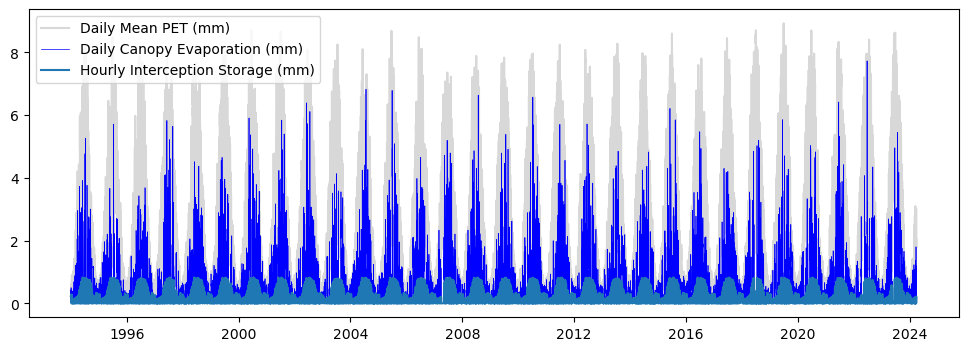

In [417]:
fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(pet_df['pet_h'].resample('D').sum(), label='Daily Mean PET (mm)', alpha=0.3, c='gray')
plt.plot(results_df['canopy_evap_hourly'].resample('D').sum(), label='Daily Canopy Evaporation (mm)', lw=0.5, c='blue')
plt.plot(results_df['interception_hourly'].resample('D').last(), label='Hourly Interception Storage (mm)')
#plt.plot(pre_hourly_df['pre_h'].resample('D').sum()[0:365], label='Daily Precipitation (mm)')
# plt.plot(mi.precip.resample('D').sum()[0:365], label='Daily Precipitation original (mm)')
# plt.plot(results_df_daily['interception'][0:2000], label='Daily Interception Storage (mm)', alpha=0.6)
plt.legend()

### Infiltration params
Clapp & Hornberger (1978): Ksat in cm/hr, b dimensionless

In [ ]:
# Clapp & Hornberger (1978): Ksat in cm/hr, b dimensionless
#https://hydrology.usu.edu/rrp/pdfs/ch4.pdf?
#Table 27
soil_params_CH = {
    "Sand": (0.395,63.36, 4.05),
    "Loamy sand": (0.410, 56.16, 4.38),
    "Sandy loam": (0.435, 12.49, 4.90),
    "Silt loam": (0.485, 2.59, 5.30),
    "Loam": (0.451, 2.50, 5.39),
    "Sandy clay loam": (0.420, 2.27, 7.12),
    "Silty clay loam": (0.477, 0.612, 7.75),
    "Clay loam": (0.476, 0.882, 8.52),
    "Sandy clay": (0.426, 0.781, 10.40),
    "Silty clay": (0.492, 0.371, 10.40),
    "Clay": (0.482, 0.461, 11.40),
}

#to df
soil_params_CH_df = pd.DataFrame.from_dict(soil_params_CH, orient='index', columns=['n', 'Ksat_cm_h', 'b'])


def get_ch_soil_params(texture: str):
    if texture not in soil_params_CH:
        raise ValueError(f"Unknown texture '{texture}'. Choose one of: {list(soil_params_CH.keys())}")
    n, Ksat_cm_h, b = soil_params_CH[texture]
    Ksat_mm_h = Ksat_cm_h * 10.0   # cm/hr -> mm/hr
    c = 2.0 * b + 3.0              # Brooks-Corey exponent
    return n, Ksat_mm_h, c


In [465]:
soil_params_CH_df.to_csv('./data/soil_water_params_CH.csv')

#### Root depth distribution for IGBP vegetation types
Acoording to Zeng (2001): https://doi.org/10.1175/1525-7541(2001)002%3C0525:GVRDFL%3E2.0.CO;2

In [418]:
# Zeng (2001) root distribution parameters for IGBP types (Table 2)
#cumulative root fraction from surface to layer: fr(z) = 1 - 0.5(exp(-a*z) + exp(-b*z))

# Units: a, b in m^-1 ; dr in m
igbp_root_params = pd.DataFrame([
    (1,  "Evergreen needleleaf tree",      6.706, 2.175, 1.8),
    (2,  "Evergreen broadleaf tree",       7.344, 1.303, 3.0),
    (3,  "Deciduous needleleaf tree",      7.066, 1.953, 2.0),
    (4,  "Deciduous broadleaf tree",       5.990, 1.955, 2.0),
    (5,  "Mixed forest",                  4.453, 1.631, 2.4),
    (6,  "Closed shrubland",              6.326, 1.567, 2.5),
    (7,  "Open shrubland",                7.718, 1.262, 3.1),
    (8,  "Woody savanna",                 7.604, 2.300, 1.7),
    (9,  "Savanna",                       8.235, 1.627, 2.4),
    (10, "Grassland",                    10.740, 2.608, 1.5),
    (11, "Permanent wetland",              np.nan, np.nan, np.nan),
    (12, "Cropland",                      5.558, 2.614, 1.5),
    (13, "Urban and built-up land",       5.558, 2.614, 1.5),
    (14, "Cropland/natural vegetation",   5.558, 2.614, 1.5),
    (15, "Snow and ice",                  np.nan, np.nan, np.nan),
    (16, "Barren",                        4.372, 0.978, 4.0),
    (17, "Water bodies",                  np.nan, np.nan, np.nan),
], columns=["igbp_id", "igbp_type", "a", "b", "dr"])

igbp_root_params = igbp_root_params.set_index("igbp_id")

In [462]:
igbp_root_params.to_csv('./data/igbp_root_params.csv')

In [419]:
def f_roots_zeng(z, a, b):
    """
    Zeng (2001) cumulative root fraction from 0..z (before trunc/renorm).
    z can be scalar or array, units must match a,b (here: meters).
    """
    z = np.asarray(z, dtype=float)
    z = np.maximum(z, 0.0)
    return 1.0 - 0.5 * (np.exp(-a * z) + np.exp(-b * z))

# Compute root fractions in each layer defined by layer_edges_m using Zeng (2001).
def root_fracs_zeng_multilayer(layer_edges_m, a, b, dr, renormalize=True):
    """
    Compute root fractions in each layer defined by layer_edges_m using Zeng (2001).

    Parameters
    ----------
    layer_edges_m : array-like
        Monotonically increasing depth edges in meters, e.g. [0, 0.3, 1.0, 2.0].
        N layers => N+1 edges.
    a, b : float
        Zeng parameters (m^-1).
    dr : float
        Rooting depth (m). Roots are truncated at dr.
    renormalize : bool
        If True, normalize so the cumulative fraction at dr is 1 (roots sum to 1
        over the rooted profile). Recommended.

    Returns
    -------
    fracs : np.ndarray, shape (n_layers,)
        Root fraction in each layer. Sums to 1 if renormalize=True and max(edge)>=dr.
        If all edges are shallower than dr, sum < 1 (only part of roots captured).
    """
    edges = np.asarray(layer_edges_m, dtype=float)
    if edges.ndim != 1 or len(edges) < 2:
        raise ValueError("layer_edges_m must be a 1D array with at least 2 elements. If only one layer, use edges [0, depth].")
    if not np.all(np.diff(edges) > 0):
        raise ValueError("layer_edges_m must be strictly increasing.")
    if dr is None or not np.isfinite(dr) or dr <= 0:
        # no defined roots
        return np.zeros(len(edges) - 1, dtype=float)
    if dr == 0:
        raise ValueError("rooting depth must be a positive number greater than zero.")

    # truncate depths at dr
    edges_t = np.minimum(edges, dr)

    # cumulative at each edge
    Y_edges = f_roots_zeng(edges_t, a, b)

    if renormalize:
        Ydr = float(f_roots_zeng(dr, a, b))
        if Ydr <= 0:
            return np.zeros(len(edges) - 1, dtype=float)
        Y_edges = Y_edges / Ydr

    # layer fractions by differencing
    fracs = np.diff(Y_edges)

    # numerical safety
    fracs = np.clip(fracs, 0.0, 1.0)

    # If you renormalize, but your deepest edge < dr, sum < 1 by construction (that’s fine).
    return fracs


# Convenience wrapper: compute multi-layer root fractions for an IGBP class.
def root_fracs_igbp_multilayer(igbp_id, layer_edges_m, igbp_params_df, renormalize=True):
    """
    Convenience wrapper: compute multi-layer root fractions for an IGBP class.
    igbp_params_df should have columns: a, b, dr indexed by igbp_id.
    """
    row = igbp_params_df.loc[igbp_id]
    a, b, dr = row["a"], row["b"], row["dr"]

    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(dr):
        return np.zeros(len(layer_edges_m) - 1, dtype=float)

    return root_fracs_zeng_multilayer(layer_edges_m, float(a), float(b), float(dr), renormalize=renormalize)



# Mix root fractions across land-cover fractions into one effective profile.
def mix_root_fracs_multilayer(lc_fractions, layer_edges_m, igbp_params_df,
                              nonveg_ids=None, renormalize=True):
    """
    Mix root fractions across land-cover fractions into one effective profile.

    Parameters
    ----------
    lc_fractions : dict
        {igbp_id: area_fraction} that sums to 1 (or close). Area fractions of each IGBP class.
    igbp_params_df : pd.DataFrame
        DataFrame with IGBP root parameters (a, b, dr) indexed by igbp_id.
    layer_edges_m : list/array
        Depth edges [0, z1, z2, ..., zN]
    nonveg_ids : set or None
        IGBP ids to treat as non-vegetated for transpiration (roots = 0).
        Example: {15, 17} (snow/ice, water). For your conceptual 'bare', you may
        choose to treat 16 as non-veg too.
    renormalize : bool
        Renormalize per-IGBP root profiles by their dr.

    Returns
    -------
    f_cell : np.ndarray (n_layers,)
        Mixed root fractions over vegetated area.
    pveg : float
        Total vegetated fraction used in the mix (sum of fractions of classes with roots).
    """
    if nonveg_ids is None:
        nonveg_ids = set()

    n_layers = len(layer_edges_m) - 1
    num = np.zeros(n_layers, dtype=float)
    pveg = 0.0

    for igbp_id, frac in lc_fractions.items():
        if frac <= 0:
            continue
        if igbp_id in nonveg_ids:
            continue

        fi = root_fracs_igbp_multilayer(igbp_id, layer_edges_m, igbp_params_df, renormalize=renormalize)

        if fi.sum() > 0:
            num += frac * fi
            pveg += frac

    if pveg <= 0:
        return np.zeros(n_layers, dtype=float), 0.0

    # Normalize by vegetated fraction so f_cell sums to 1 over transpiring area
    f_cell = num / pveg

    # safety normalize (small numeric drift)
    s = f_cell.sum()
    if s > 0:
        f_cell = f_cell / s

    return f_cell, pveg

In [427]:
### example usage:
layer_edges = [0.0, 0.05, 0.5, 1.5, 2.0]  # meters => 4 layers

lc_fractions = {
    10: 0.5,  # grassland
    4:  0.4,  # deciduous broadleaf forest
    16: 0.1,  # "bare" in your conceptual sense
}

# If your "bare" truly has no transpiration, treat IGBP 16 as non-veg:
nonveg = {16, 15, 17}  # bare + snow/ice + water bodies

f_cell, pveg = mix_root_fracs_multilayer(lc_fractions, layer_edges, igbp_root_params,
                                         nonveg_ids=nonveg, renormalize=True)

print("Vegetated fraction:", pveg)
print("Layer root fractions:", f_cell)
print("Sum:", f_cell.sum())

Vegetated fraction: 0.9
Layer root fractions: [0.22988551 0.60706805 0.15556203 0.0074844 ]
Sum: 1.0


In [430]:
def allocate_transpiration_root_water_stress(Tpot, f_root, stress, sm, z_layers, s_wp, max_passes=None, eps=1e-12):

    """  
    Allocate potential transpiration Tpot (mm) into layers based on root
    fractions f_root, soil moisture stress factors stress, soil moisture sm,
    layer thicknesses z_layers, and wilting point s_wp.
    Iteratively allocate water from layers until Tpot is met or no more water
    can be extracted.
    Parameters
    ----------
    Tpot : float
        Potential transpiration (mm).
    f_root : array-like, shape (N,)
        Root fractions per layer (sums to 1 over rooted layers).
    stress : array-like, shape (N,)
        Soil moisture stress factors per layer (0..1).
    sm : array-like, shape (N,)
        Soil moisture per layer (mm/mm).
    z_layers : array-like, shape (N,)
        Layer thicknesses (mm).
    s_wp : array-like, shape (N,)
        Wilting point soil moisture per layer (mm/mm).
    max_passes : int or None
        Maximum number of allocation passes. If None, set to N (number of layers).
    eps : float
        Small threshold to avoid numerical issues.
    
    Returns
    -------
    T : np.ndarray, shape (N,)
        Actual transpiration allocated per layer (mm).
    unmet : float
        Unmet transpiration demand (mm).
    """
    f_root = np.asarray(f_root, dtype=float)
    stress = np.asarray(stress, dtype=float)
    sm = np.asarray(sm, dtype=float)
    z_layers = np.asarray(z_layers, dtype=float)
    s_wp = np.asarray(s_wp, dtype=float)

    # safety checks
    N = len(f_root)
    if max_passes is None:
        max_passes = N

    # extractable water per layer
    w_avail_layer = np.maximum(0.0, (sm - s_wp) * z_layers)      # extractable water (mm)
    rooted = f_root > 0.0

    # initialize transpiration array
    T_layer = np.zeros(N, dtype=float)
    demand = float(max(0.0, Tpot))

    for _ in range(max_passes):
        if demand <= eps:
            break
        
        # remaining extractable water
        remain_water = np.maximum(0.0, w_avail_layer - T_layer)
        remain_water[~rooted] = 0.0

        # weighted allocation of remaining demand
        w = f_root * remain_water * stress
        w[~rooted] = 0.0
        wsum = w.sum()
        if wsum <= eps:
            break

        # allocate proportionally
        add = demand * (w / wsum)
        add = np.minimum(add, remain_water)

        T_layer += add
        demand = float(max(0.0, Tpot - T_layer.sum()))

    unmet = float(max(0.0, Tpot - T_layer.sum()))
    return T_layer, unmet

In [432]:
def sm_stress_linear(sm, s_fc, s_wp):
    # 1 at/above FC, 0 at/below WP
    if s_fc <= s_wp:
        return 0.0
    return float(np.clip((sm - s_wp) / (s_fc - s_wp), 0.0, 1.0))


def _as_layer_array(x, n_layers, name="param"):
    """
    Assert x is scalar or length n_layers, return as np.ndarray of shape (n_layers,).
    Parameters
    ----------
    x : scalar or array-like
        Input parameter.
    n_layers : int
        Number of layers.
    name : str
        Name of the parameter (for error messages).
    """
    if np.isscalar(x):
        return np.full(n_layers, float(x), dtype=float)
    arr = np.asarray(x, dtype=float)
    if arr.size != n_layers:
        raise ValueError(f"{name} must be scalar or length {n_layers}. Got {arr.size}.")
    return arr

In [ ]:
#soil water balance with N layers
def soil_water_balance_nlayers(
    model_fluxes,
    forcing,
    z_layers,                     # list/array of mm thicknesses, length N
    s_sat, s_fc, s_wp,            # scalar or length N
    S,                            # sorptivity for infiltration model (you can later make this per-layer too)
    soil_textures,                # list of strings length N (texture per layer)
    model_name="valiantzas_model",
    sim_freq="H",
    sm_r=None,                 #residual soil moisture
    drain_above_fc=False,
):
    
    # Determine time step
    dt_hours = 1.0 if sim_freq.upper() == "H" else 24.0
    n_timesteps = len(model_fluxes["index"])

    z_layers = np.asarray(z_layers, dtype=float)
    n_layers = len(z_layers)

    s_sat = _as_layer_array(s_sat, n_layers, "s_sat")
    s_fc  = _as_layer_array(s_fc,  n_layers, "s_fc")
    s_wp  = _as_layer_array(s_wp,  n_layers, "s_wp")

    if sm_r is None:
        sm_r = s_wp.copy()
    sm_r = _as_layer_array(sm_r, n_layers, "sm_r")

    if len(soil_textures) != n_layers:
        raise ValueError(f"soil_textures must have length {n_layers} (one texture per layer).")

    # --- lookup hydraulic params per layer ---
    # get_ch_params(texture) -> (n_ret, Ks_lut, c_exp)
    Ks_lut = np.zeros(n_layers, dtype=float)
    c_exp  = np.zeros(n_layers, dtype=float)
    for k in range(n_layers):
        _, Ks_k, c_k = get_ch_params(soil_textures[k])
        Ks_lut[k] = float(Ks_k)
        c_exp[k]  = float(c_k)

    # Infiltration capacity uses top-layer parameters (conceptual but common)
    infil_model = InfiltrationModel(Ks_lut[0], S)

    throughfall_t = model_fluxes["throughfall"]

    def K_unsat(sm, k):
        """Brooks–Corey: K = Ks * Se^c, layer k."""
        denom = (s_sat[k] - sm_r[k])
        Se = (sm - sm_r[k]) / denom if denom > 0 else 0.0
        Se = float(np.clip(Se, 0.0, 1.0))
        return Ks_lut[k] * (Se ** c_exp[k])  # mm/h

    # Ensure percolation arrays exist (if user forgot initializer)
    for k in range(1, n_layers):
        key = f"percolation_L{k}L{k+1}"
        if key not in model_fluxes:
            model_fluxes[key] = np.zeros(n_timesteps, dtype=float)
    recharge_key = f"recharge_L{n_layers}"
    if recharge_key not in model_fluxes:
        model_fluxes[recharge_key] = np.zeros(n_timesteps, dtype=float)

    # ============================= time loop for infiltration and drainage =============================
    for t in range(n_timesteps):
        # --- read previous soil moisture states ---

        sm_prev = np.zeros(n_layers, dtype=float)

        for k in range(n_layers):
            key = f"soil_moisture_L{k+1}"
            sm_prev[k] = model_fluxes[key][t-1] if t > 0 else model_fluxes[key][0]

        sm = sm_prev.copy()

        # ---------------- Surface -> L1 infiltration ----------------
        # available space in L1 (mm)
        sc1_mm = max(0.0, (s_sat[0] - sm[0]) * z_layers[0])  # space to saturation (mm)

        # infiltration capacity over dt using the chosen model
        F = float(infil_model.models[model_name](dt_hours))     # mm over dt
        inf_cap = max(0.0, F)

        # actual infiltration limited by capacity and available space
        infil = min(inf_cap, float(throughfall_t[t]), sc1_mm)
        model_fluxes["infiltration"][t] = infil

        # excess infiltration becomes surface runoff
        infil_excess = max(0.0, float(throughfall_t[t]) - infil)

        # update soil moisture in L1
        sm[0] += infil / z_layers[0]

        # saturation excess runoff at surface (only L1 can saturate-excess here)
        sat_ex1 = 0.0
        if sm[0] > s_sat[0]:
            sat_ex1 = (sm[0] - s_sat[0]) * z_layers[0]
            sm[0] = s_sat[0]

        model_fluxes["surface_run_off"][t] = infil_excess + sat_ex1

        # =================== ET BEFORE DRAINAGE =====================
        #Plant transpiration and soil evaporation before drainage
        # For simplicity, we assume that soil evaporation is taken from the top layer only.
                
        pet_t = float(forcing["pet_h"].iloc[t]) if sim_freq.upper() == "H" else float(forcing["pet_d"].iloc[t])
        can_ev = float(model_fluxes["canopy_evap"][t])

        if can_ev >= pet_t:
            # canopy satisfies all PET, no vegetation transpiration
            model_fluxes["evap_actual_bs"][t] = 0.0
            model_fluxes["total_evap"][t] = pet_t
            for k in range(n_layers):
                model_fluxes[f"aET_L{k+1}"][t] = 0.0
        else:
            remaining_PET = pet_t - can_ev

            # ---- land fractions (better to pass in) ----
            f_cell, pveg = mix_root_fracs_multilayer(lc_fractions, layer_edges, igbp_root_params,
                                         nonveg_ids=nonveg, renormalize=True)
            pveg = 0.9
            pbare = 1- pveg

            # ---- stress per layer (based on current sm after infiltration) ----
            stress = np.zeros(n_layers, dtype=float)
            for k in range(n_layers):
                stress[k] = sm_stress_linear(sm[k], s_fc[k], s_wp[k])

            # ---- transpiration demand over vegetated fraction ----
            Tpot = pveg * remaining_PET

            # ---- root fractions per layer (length n_layers, sum=1 over veg) ----
            f_root = f_cell  

            # ---- allocate transpiration across layers ----
            T_layers, unmet_T = allocate_transpiration_root_water_stress(
                Tpot=Tpot,
                f_root=f_root,
                stress=stress,
                sm=sm,
                z_layers=z_layers,
                s_wp=s_wp,
                max_passes=n_layers
            )

            # apply transpiration
            for k in range(n_layers):
                model_fluxes[f"aET_L{k+1}"][t] = T_layers[k]
                sm[k] -= T_layers[k] / z_layers[k]

            # ---- bare soil evaporation from top layer only ----
            Esoil_pot = pbare * remaining_PET
            Wtop = max(0.0, (sm[0] - s_wp[0]) * z_layers[0])
            Esoil = min(Esoil_pot, Wtop)

            model_fluxes["evap_actual_bs"][t] = Esoil
            sm[0] -= Esoil / z_layers[0]

            model_fluxes["total_evap"][t] = can_ev + T_layers.sum() + Esoil


        # ---------------- Drainage L1->L2->...->LN (unit gradient) ----------------
        for k in range(n_layers - 1):
            
            # potential percolation from layer k to k+1 over dt
            Kk = K_unsat(sm[k], k)             # mm/h
            Fk_pot = Kk * dt_hours                # mm

            # available water in layer k (mm)
            if drain_above_fc:
                Wavail = max(0.0, (sm[k] - s_fc[k]) * z_layers[k])
            else:
                Wavail = max(0.0, (sm[k] - sm_r[k]) * z_layers[k])

            # available space in layer k+1 (mm)
            Wspace = max(0.0, (s_sat[k+1] - sm[k+1]) * z_layers[k+1])

            # actual percolation
            Fk = min(Fk_pot, Wavail, Wspace)

            # update soil moistures
            sm[k]   -= Fk / z_layers[k]
            sm[k+1] += Fk / z_layers[k+1]

            model_fluxes[f"percolation_L{k+1}L{k+2}"][t] = Fk

        # ---------------- Bottom recharge from layer N ----------------
        Kb = K_unsat(sm[n_layers-1], n_layers-1)
        Fb_pot = Kb * dt_hours

        if drain_above_fc:
            Wavail_b = max(0.0, (sm[n_layers-1] - s_fc[n_layers-1]) * z_layers[n_layers-1])
        else:
            Wavail_b = max(0.0, (sm[n_layers-1] - sm_r[n_layers-1]) * z_layers[n_layers-1])

        Fb = min(Fb_pot, Wavail_b)
        sm[n_layers-1] -= Fb / z_layers[n_layers-1]
        model_fluxes[recharge_key][t] = Fb

In [ ]:
def soil_water_balance(
    model_fluxes,
    forcing,
    z1, z2,
    s_sat, s_fc, s_wp,
    S,
    soil_texture="Sandy loam",     # soil texture for hydraulic parameters
    model_name="valiantzas_model",
    sim_freq="H",
    sm_r=None,            # <-- set inside (defaults to s_wp)
    drain_above_fc=False,
):
    # --- set residual ---
    if sm_r is None:
        sm_r = s_wp

    # --- lookup-table soil water retention-based params ---
    n, Ks_lut, c = get_ch_soil_params(soil_texture)

    # 2) Use user-defined Ks for infiltration capacity, LUT Ks for drainage:
    dt_hours = 1.0 if sim_freq.upper() == "H" else 24.0
    n = len(model_fluxes["index"])

    throughfall_t = model_fluxes["throughfall"]
    infil_model = InfiltrationModel(Ks_lut, S)

    # ensure arrays exist
    if "soil_moisture_L2" not in model_fluxes:
        model_fluxes["soil_moisture_L2"] = np.zeros(n, dtype=float)
    if "percolation_L1L2" not in model_fluxes:
        model_fluxes["percolation_L1L2"] = np.zeros(n, dtype=float)
    if "recharge_L2" not in model_fluxes:
        model_fluxes["recharge_L2"] = np.zeros(n, dtype=float)

    def K_unsat(n):
        # Brooks–Corey law: K = Ks * Se^n
        Se = (n - sm_r) / (s_sat - sm_r) if (s_sat > sm_r) else 0.0
        Se = float(np.clip(Se, 0.0, 1.0))
        return Ks_lut * (Se ** c)  # mm/h

    #==================== Infiltration to Layer 1 =====================
    for t in range(n):
        # ---------------- Current soil moistures for layers 1 and 2----------------
        sm1_prev = model_fluxes["soil_moisture_L1"][t-1] if t > 0 else model_fluxes["soil_moisture_L1"][0]
        sm2_prev = model_fluxes["soil_moisture_L2"][t-1] if t > 0 else model_fluxes["soil_moisture_L2"][0]

        # ---------------- Surface -> L1 infiltration ----------------
        sc1_mm = max(0.0, (s_sat - sm1_prev) * z1)  # storage to sat in L1 (mm)

        #Infiltration capacity from selected model after dt timesteps
        F = float(infil_model.models[model_name](dt_hours))  # mm over dt
        inf_cap = max(0.0, F)

        infil = min(inf_cap, float(throughfall_t[t]), sc1_mm)
        model_fluxes["infiltration"][t] = infil

        infil_excess = max(0.0, float(throughfall_t[t]) - infil)

        sm1 = sm1_prev + infil / z1

        sat_ex1 = 0.0
        if sm1 > s_sat:
            sat_ex1 = (sm1 - s_sat) * z1
            sm1 = s_sat

        model_fluxes["surface_run_off"][t] = infil_excess + sat_ex1

        # ----------------Drainage from Layer1 to Layer 2 following Brooks–Corey drainage (unit gradient) ----------------
        K1 = K_unsat(sm1)               # mm/h

        #Potential drainage from L1 to L2 over dt
        F12_pot = K1 * dt_hours         # mm

        #available water for drainage from layer 1
        if drain_above_fc:
            Wavail1 = max(0.0, (sm1 - s_fc) * z1)  # drainable above field capacity
        else:
            Wavail1 = max(0.0, (sm1 - sm_r) * z1)  # drainable above residual

        Wspace2 = max(0.0, (s_sat - sm2_prev) * z2)    # space to saturation in L2 (mm)

        F12 = min(F12_pot, Wavail1, Wspace2)           # actual transfer (mm)

        sm1 -= F12 / z1 # update L1 soil moisture
        sm2 = sm2_prev + F12 / z2 # update L2 soil moisture

        model_fluxes["percolation_L1L2"][t] = F12 # actual transfer from L1 to L2

        #Deep percolation / recharge from L2 to groundwater
        K2 = K_unsat(sm2)               # mm/h
        Fg_pot = K2 * dt_hours         # mm

        if drain_above_fc:
            Wavail2 = max(0.0, (sm2 - s_fc) * z2)  # drainable above field capacity in L2
        else:
            Wavail2 = max(0.0, (sm2 - sm_r) * z2)  # drainable above residual in L2
        Fg = min(Fg_pot, Wavail2)      # actual recharge (mm)
        sm2 -= Fg / z2                  # update L2 soil moisture
        model_fluxes["recharge_L2"][t] = Fg

        
        # =================== ET partition from L1 only) =====================
        pet_t = float(forcing["pet_h"].iloc[t]) if sim_freq.upper() == "H" else float(forcing["pet_d"].iloc[t])
        can_ev = float(model_fluxes["canopy_evap"][t])

        if can_ev >= pet_t:
            model_fluxes["total_evap"][t] = pet_t
            model_fluxes["evap_actual_tc"][t] = 0.0
            model_fluxes["evap_actual_sc"][t] = 0.0
            model_fluxes["evap_actual_bs"][t] = 0.0
            soil_ET = 0.0
        else:
            remaining_PET = pet_t - can_ev

            #stress factors for each layer
            stress_L1 = sm_stress_linear(sm1, s_fc, s_wp)
            stress_L2 = sm_stress_linear(sm2, s_fc, s_wp)

            #calculate vegetation transpiration fractions


            E_tc = 1.0 - stress_L1**2
            E_sc = max(0.0, 0.5*(1.0 - np.sqrt(stress_L1) + tau/0.8))
            E_bs = 1.0 - np.sqrt(stress_L1)
            

            model_fluxes["E_stress_tc"][t] = E_tc
            model_fluxes["E_stress_sc"][t] = E_sc
            model_fluxes["E_stress_bs"][t] = E_bs

            pot_tc = remaining_PET * frac_tall_canopy  * alpha_tall_canopy
            pot_sc = remaining_PET * frac_short_canopy * alpha_short_canopy
            pot_bs = remaining_PET * frac_bare_soil    * alpha_bare_soil

            a_tc = pot_tc * E_tc
            a_sc = pot_sc * E_sc
            a_bs = pot_bs * E_bs

            model_fluxes["evap_actual_tc"][t] = a_tc
            model_fluxes["evap_actual_sc"][t] = a_sc
            model_fluxes["evap_actual_bs"][t] = a_bs

            soil_ET = a_tc + a_sc + a_bs
            model_fluxes["total_evap"][t] = can_ev + soil_ET

        # remove soil_ET from L1 (you can later allow uptake from L2 if desired)
        sm1 -= soil_ET / z1

        # enforce bounds
        sm1 = float(np.clip(sm1, s_wp, s_sat))
        sm2 = float(np.clip(sm2, s_wp, s_sat))

        model_fluxes["soil_moisture_L1"][t] = sm1
        model_fluxes["soil_moisture_L2"][t] = sm2

    return model_fluxes


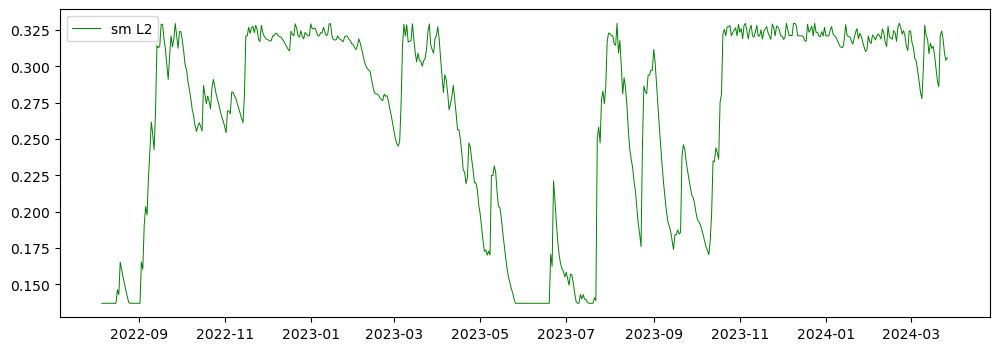

In [406]:
fig, ax = plt.subplots(figsize=(12, 4))
# plt.plot(mi.pET_k, alpha=0.7, label='Potential Evapotranspiration (mm)', color='orange')
plt.plot(results_df_full['soil_moisture_L1'].resample('D').sum()[-600:], label='sm L2', color='g', lw=0.7)
# plt.plot(results_df_full['recharge_L2'].resample('ME').sum(), label=' Soil moisture Layer 2 (mm)', color='b', lw=0.7)
plt.legend()

In [531]:
import math

def compute_PTF_params(sand_pct: float, clay_pct: float, Db: float):
    """
    PTF from Zacharias & Wessolek (2007) doi:10.2136/sssaj2006.0098.
    This function computes van Genuchten parameters from soil texture and bulk density (Equations 4 and 5 in the paper).
    Inputs:
      sand_pct, clay_pct : % by weight (0–100)
      Db           : bulk density (g/cm3)
    Returns:
      van Genuchten parameters.
      theta_r, theta_s, alpha (1/kPa), n, m: residual and saturated soil moisture, alpha, n, m coefficients.

    """
    theta_r = 0.0  # θr set to zero in the calibration according to the paper

    #sand and clay percentages must be between 0 and 100
    sand_pct = max(0.0, min(100.0, sand_pct))
    clay_pct = max(0.0, min(100.0, clay_pct))

    if sand_pct + clay_pct > 100.0:
        raise ValueError("Sum of sand_pct and clay_pct cannot exceed 100.")

    #Equation 4 in the paper
    if sand_pct < 66.5:
        theta_s = 0.788 + 0.001 * clay_pct - 0.263 * Db 
        ln_alpha = -0.648 + 0.023 * sand_pct + 0.044 * clay_pct - 3.168 * Db
        n = 1.392 - 0.418 * (sand_pct ** (-0.024)) + 1.212 * (clay_pct ** (-0.704))
    else:
        #Equation 5 in the paper
        theta_s = 0.890 - 0.001 * clay_pct - 0.322 * Db
        ln_alpha = -4.197 + 0.013 * sand_pct + 0.076 * clay_pct - 0.276 * Db
        n = -2.562 + (7e-9) * (sand_pct ** 4.004) + 3.750 * (clay_pct ** (-0.016))

    alpha = math.exp(ln_alpha)
    m = 1.0 - (1.0 / n)
    return theta_r, theta_s, alpha, n, m

def theta_vg(h_kpa: float, theta_r: float, theta_s: float, alpha: float, n: float, m: float):
    """
    van Genuchten θ(h) using suction |h| in kPa.

    Equation 1 in the paper.
    """
    h = abs(h_kpa)
    return theta_r + (theta_s - theta_r) / ((1.0 + (alpha * h) ** n) ** m)

def soil_water_retention(sand_pct: float, clay_pct: float, Db: float, fc_kpa: float = 33.0):
    """
    Returns θsat, θFC(at 33 kPa by default), θWP(at 1500 kPa), plus VG params.
    """
    th_r, th_s, alpha, n, m = compute_PTF_params(sand_pct, clay_pct, Db)
    return {
        "theta_sat": th_s,  # θsat = θs
        "theta_fc":  theta_vg(fc_kpa,  th_r, th_s, alpha, n, m),
        "theta_wp":  theta_vg(1500.0,  th_r, th_s, alpha, n, m),
        "vg_params": {"theta_r": th_r, "theta_s": th_s, "alpha_1_per_kpa": alpha, "n": n, "m": m},
        "fc_kpa": fc_kpa
    }


In [534]:
sw = soil_water_retention(sand_pct=70.0, clay_pct=25.0, Db=1.50, fc_kpa=33.0)

In [535]:
sw

{'theta_sat': 0.382,
 'theta_fc': 0.28067962885986325,
 'theta_wp': 0.14904017363212343,
 'vg_params': {'theta_r': 0.0,
  'theta_s': 0.382,
  'alpha_1_per_kpa': 0.1651336719552661,
  'n': 1.170707102193418,
  'm': 0.14581538104072644},
 'fc_kpa': 33.0}

In [ ]:
from config_loader import load_inputs_from_nml

inputs = load_inputs_from_nml("config.nml")

print("sim_freq:", inputs.sim_freq)
print("n_layers:", inputs.n_layers)
print("soil_textures:", inputs.soil_textures)
print("Ks (mm/h):", inputs.soil_params_layer["Ks_mm_h"])
print("b (Brooks-Corey):", inputs.soil_params_layer["b"])
print("theta_fc:", inputs.soil_params_layer["theta_fc"])
print("theta_wp:", inputs.soil_params_layer["theta_wp"])
print("meteo period:", inputs.meteo_data.index.min(), "->", inputs.meteo_data.index.max())
print("dailyLAI length:", len(inputs.dailyLAI))
